# PCA — Overview: Putting It All Together

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V08a — "PCA: Overview" (DeepLearning.AI).*

Time to assemble the full algorithm. PCA cleverly combines the **three** ideas from this lesson:

1. **Projection** — a matrix multiply moves data into fewer dimensions.
2. **Eigenvalues & eigenvectors** — the directions a transformation only stretches.
3. **The covariance matrix** — a compact summary of the data's spread and relationships.

The punchline: **project onto the eigenvectors of the covariance matrix, keeping the largest eigenvalues.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The PCA steps on a 2D example

Start with data **centered** at its mean. Suppose its covariance matrix is

$$ C = \begin{pmatrix} 9 & 4 \\ 4 & 3 \end{pmatrix} \quad (\mathrm{Var}(x)=9,\; \mathrm{Var}(y)=3,\; \mathrm{Cov}=4\ \text{— a positive trend}). $$

**The big leap:** find the **eigenvalues and eigenvectors of $C$**. They are:

- $v_1 = (2, 1)$ with eigenvalue $\lambda_1 = 11$,
- $v_2 = (-1, 2)$ with eigenvalue $\lambda_2 = 1$.

These are the **principal components**.

In [2]:
C = np.array([[9, 4],
              [4, 3]])
eigvals, eigvecs = np.linalg.eigh(C)   # eigh: symmetric matrices, ascending order
# sort descending by eigenvalue
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
print('eigenvalues (desc):', eigvals)          # 11, 1
for i in range(2):
    v = eigvecs[:, i] / eigvecs[:, i][np.argmax(np.abs(eigvecs[:, i]))]
    print(f'lambda = {eigvals[i]:.0f}: principal component direction {v}')

eigenvalues (desc): [11.  1.]
lambda = 11: principal component direction [1.  0.5]
lambda = 1: principal component direction [-0.5  1. ]


## 2. Principal components are orthogonal

The two eigenvectors sit at **90°** to each other — they're **orthogonal**. This is no accident: the eigenvectors of any **symmetric** matrix are always orthogonal, and **every covariance matrix is symmetric** (since $\mathrm{Cov}(x,y)=\mathrm{Cov}(y,x)$). So PCA's principal components are guaranteed to be perpendicular.

In [3]:
v1, v2 = eigvecs[:, 0], eigvecs[:, 1]
print('C symmetric:', np.allclose(C, C.T))
print('v1 . v2 =', round(v1 @ v2, 12), ' -> orthogonal (perpendicular)')

C symmetric: True
v1 . v2 = 0.0  -> orthogonal (perpendicular)


## 3. The largest eigenvalue wins

Which component to project onto? **The eigenvector with the largest eigenvalue gives the greatest variance** when you project the data onto it. Here $v_1=(2,1)$ has $\lambda_1 = 11 \gg 1$, so it's the winner — that's the line to keep. We **discard** $v_2$ (eigenvalue $1$).

In fact the eigenvalue **equals the variance** of the projected data along that component — so $\lambda$ directly measures how much information each principal component carries.

In [4]:
# Generate data whose covariance is ~ C, then confirm the eigenvalue = projected variance
rng = np.random.default_rng(0)
L = np.linalg.cholesky(C)
data = (L @ rng.normal(size=(2, 4000))).T   # samples with covariance ~ C
data = data - data.mean(axis=0)             # center

for i in range(2):
    v = eigvecs[:, i]
    projected = data @ v                     # 1-D coordinates along this component
    print(f'component {i+1}: eigenvalue = {eigvals[i]:.2f}, projected variance = {projected.var(ddof=1):.2f}')

component 1: eigenvalue = 11.00, projected variance = 10.97
component 2: eigenvalue = 1.00, projected variance = 1.01


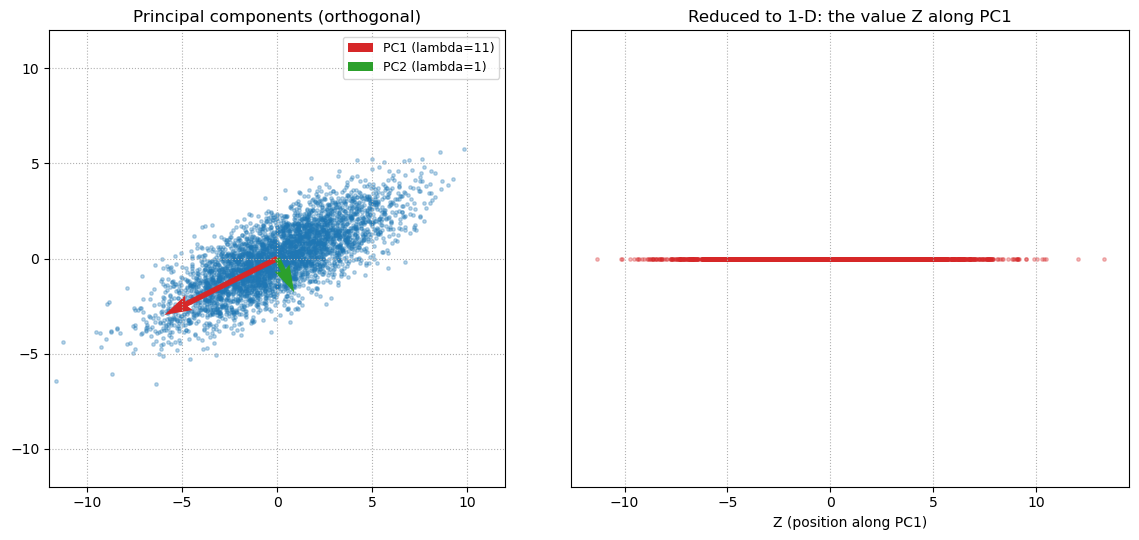

data went from 2-D (x, y) to 1-D (Z), keeping the maximum variance


In [5]:
# Visualize: the two principal components, then the projection onto the winner
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
opts = dict(angles='xy', scale_units='xy', scale=1)
ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], s=6, color='C0', alpha=0.3)
ax.quiver(0, 0, *(eigvecs[:, 0]*np.sqrt(eigvals[0])*2), color='C3', width=0.012, **opts, label=f'PC1 (lambda={eigvals[0]:.0f})')
ax.quiver(0, 0, *(eigvecs[:, 1]*np.sqrt(eigvals[1])*2), color='C2', width=0.012, **opts, label=f'PC2 (lambda={eigvals[1]:.0f})')
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(fontsize=9); ax.set_title('Principal components (orthogonal)')
ax.set_xlim(-12, 12); ax.set_ylim(-12, 12)

ax = axes[1]
z = data @ eigvecs[:, 0]                     # project onto PC1 -> single value Z
ax.scatter(z, np.zeros_like(z), s=6, color='C3', alpha=0.3)
ax.set_yticks([]); ax.grid(True, ls=':'); ax.set_title('Reduced to 1-D: the value Z along PC1')
ax.set_xlabel('Z (position along PC1)')
plt.tight_layout(); plt.show()
print('data went from 2-D (x, y) to 1-D (Z), keeping the maximum variance')

## 4. The general algorithm (any dimensions)

The same recipe scales to any size. For a dataset with $d$ features and $n$ observations, to reduce to $k$ dimensions:

1. **Center** the data (subtract the column means).
2. Compute the $d \times d$ **covariance matrix** $C$.
3. Find the **eigenvalues and eigenvectors** of $C$; **sort** by eigenvalue, largest first.
4. **Keep the top $k$** eigenvectors and stack them (normalized) as columns of $V$ ($d \times k$).
5. **Project**: $A_P = A\,V$ — an $n \times k$ dataset with the maximum retained variance.

In [6]:
def pca(A, k):
    A_centered = A - A.mean(axis=0)
    C = np.cov(A_centered.T, ddof=1)
    vals, vecs = np.linalg.eigh(C)              # symmetric -> real, orthogonal
    order = np.argsort(vals)[::-1]              # largest eigenvalue first
    vals, vecs = vals[order], vecs[:, order]
    V = vecs[:, :k]                             # top-k components (already unit norm)
    return A_centered @ V, vals

# Demo: reduce a 9-dimensional dataset to 2 dimensions
rng = np.random.default_rng(3)
n, d = 500, 9
latent = rng.normal(size=(n, 2))               # true structure is 2-D
mix = rng.normal(size=(2, d))
A9 = latent @ mix + rng.normal(scale=0.1, size=(n, d))   # embedded in 9-D with noise

reduced, eigenvalues = pca(A9, k=2)
print('original shape :', A9.shape)
print('reduced shape  :', reduced.shape)
print('eigenvalues (desc):', eigenvalues)
print('variance kept by top 2 components: {:.1%}'.format(eigenvalues[:2].sum() / eigenvalues.sum()))

original shape : (500, 9)
reduced shape  : (500, 2)
eigenvalues (desc): [11.432  3.82   0.012  0.012  0.011  0.01   0.009  0.008  0.008]
variance kept by top 2 components: 99.5%


## Summary — the PCA algorithm

1. **Center** the data at its mean.
2. Build the **covariance matrix** $C = \frac{1}{n-1}(A-\mu)^T(A-\mu)$.
3. Find the **eigenvectors/eigenvalues** of $C$ — the **principal components** (always **orthogonal**, since $C$ is symmetric).
4. **Sort** by eigenvalue (largest = most variance = most information) and **keep the top $k$**; the eigenvalue *is* the variance along that component.
5. **Project** onto them ($A_P = AV$) to get a $k$-dimensional dataset with the **maximum possible retained variance**.

That's PCA: eigenvectors of the covariance matrix give the best directions, and their eigenvalues tell you how much information each keeps.